# Hyperparameter Grid Search

This notebook contains code to perform grid searches over hyperparameter combinations for the various training algorithms tested for this project

In [9]:
import warnings
import logging
import itertools
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from data import build_random_dag, generate_random_dataset
from training import learn_dag

logging.getLogger('castle').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

##### Training code

In [10]:
def _edge_metrics(true_edges: set, learned_edges: set) -> dict:
    """Directed-edge recovery metrics: SHD, precision, recall, F1.

    Reversed edges (u→v learned when v→u is true) count as one mistake in SHD
    and are excluded from TP for both precision and recall.
    """
    reversed_edges = {(v, u) for u, v in true_edges} & learned_edges
    tp  = len(true_edges & learned_edges)
    fp  = len(learned_edges - true_edges - reversed_edges)
    fn  = len(true_edges - learned_edges - {(v, u) for u, v in reversed_edges})
    rev = len(reversed_edges)
    shd = fp + fn + rev
    precision = tp / (tp + fp + rev) if (tp + fp + rev) > 0 else 0.0
    recall    = tp / (tp + fn + rev) if (tp + fn + rev) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"shd": shd, "precision": precision, "recall": recall, "f1": f1}


def grid_search(data, algorithm: str, param_grid: dict, gt_dag):
    """Grid search over all combinations in param_grid.

    For each combination the algorithm is run on *data* and the resulting
    edges are scored against *gt_dag*.

    Args:
        data:       Training dataset (pd.DataFrame).
        algorithm:  Algorithm name forwarded to learn_dag.
        param_grid: Mapping of parameter name → list of candidate values.
        gt_dag:     Ground-truth DAG (networkx DiGraph).

    Returns:
        best_result: TrainingResult for the combination with the highest F1.
        results_df:  DataFrame with one row per parameter combination,
                     columns = param names + [n_learned, shd, precision, recall, f1].
    """
    true_edges  = set(gt_dag.edges())
    param_names = list(param_grid.keys())
    rows        = []
    best_result, best_f1 = None, -1.0

    n_combos = 1
    for v in param_grid.values():
        n_combos *= len(v)
    print(f"Grid: {' × '.join(str(len(v)) for v in param_grid.values())} = {n_combos} combinations\n")

    for param_values in itertools.product(*param_grid.values()):
        params = dict(zip(param_names, param_values))
        result = learn_dag(data, algorithm, **params)
        m      = _edge_metrics(true_edges, result.edges)
        rows.append({**params, "n_learned": len(result.edges), **m})
        if m["f1"] > best_f1:
            best_f1, best_result = m["f1"], result

    return best_result, pd.DataFrame(rows)

##### Reporting code

In [11]:
_METRICS      = ["shd", "precision", "recall", "f1", "n_learned"]
_METRIC_PLOTS = [
    ("f1",        "F1 ↑",        "YlGn",    False),
    ("shd",       "SHD ↓",       "YlOrRd",  True),
    ("precision", "Precision ↑", "Blues",   False),
    ("recall",    "Recall ↑",    "Purples", False),
]


def _marginal(results_df, param_grid, row_param, col_param):
    """Average metrics over all parameters except the given pair."""
    other = [p for p in param_grid if p not in (row_param, col_param)]
    return (
        results_df.groupby([row_param, col_param])[_METRICS].mean().reset_index()
        if other else results_df
    )


def plot_heatmaps(results_df, param_grid):
    """One 2×2 heatmap figure per pair of parameters in param_grid.
    Extra parameters beyond the pair are averaged out."""
    for row_param, col_param in combinations(param_grid.keys(), 2):
        df   = _marginal(results_df, param_grid, row_param, col_param)
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        for ax, (col, label, cmap, reverse) in zip(axes.flatten(), _METRIC_PLOTS):
            pivot = df.pivot(index=row_param, columns=col_param, values=col)
            sns.heatmap(
                pivot, ax=ax,
                cmap=cmap + "_r" if reverse else cmap,
                annot=pivot.round(2), fmt=".2f",
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": label},
                vmin=pivot.values.min(), vmax=pivot.values.max(),
            )
            ax.set_title(label, fontsize=12, fontweight="bold")
            ax.set_xlabel(col_param)
            ax.set_ylabel(row_param)
        other = [p for p in param_grid if p not in (row_param, col_param)]
        extra = f"  (avg over: {', '.join(other)})" if other else ""
        fig.suptitle(f"{row_param} × {col_param}{extra}", fontsize=13, y=1.01)
        fig.tight_layout()
        fname = f"notears_gridsearch_heatmaps_{row_param}_x_{col_param}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved → {fname}")


def plot_line_profiles(results_df, param_grid, best_params):
    """F1 and SHD vs each individual parameter, all others fixed at best values."""
    param_names = list(param_grid.keys())
    colors = ["steelblue", "darkorange", "seagreen", "orchid"]
    fig, axes = plt.subplots(2, len(param_names),
                             figsize=(5 * len(param_names), 8),
                             squeeze=False)
    for col_idx, param in enumerate(param_names):
        mask = pd.Series(True, index=results_df.index)
        for other, val in best_params.items():
            if other != param:
                mask &= results_df[other] == val
        slice_df  = results_df[mask].sort_values(param)
        fixed_str = ", ".join(f"{k}={v}" for k, v in best_params.items() if k != param)
        for row_idx, (metric, label) in enumerate([("f1", "F1"), ("shd", "SHD")]):
            ax = axes[row_idx][col_idx]
            ax.plot(slice_df[param].astype(str), slice_df[metric],
                    marker="o", color=colors[col_idx % len(colors)])
            ax.set_title(f"{label} vs {param}\n({fixed_str})", fontsize=9)
            ax.set_xlabel(param)
            ax.set_ylabel(label)
            ax.grid(axis="y", alpha=0.4)
    fig.suptitle("Effect of each hyperparameter  (others fixed at best values)", fontsize=13)
    fig.tight_layout()
    plt.savefig("notears_gridsearch_profiles.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → notears_gridsearch_profiles.png")


def plot_scatter(results_df, param_grid):
    """Precision–Recall scatter for all combinations.
    First two params drive color/marker; any extras are averaged out.
    Bubble size is proportional to SHD (smaller = better)."""
    param_names = list(param_grid.keys())
    p0, p1 = param_names[0], param_names[1]
    df     = _marginal(results_df, param_grid, p0, p1)
    p0_vals = sorted(df[p0].unique())
    p1_vals = sorted(df[p1].unique())
    colors  = plt.cm.tab10(np.linspace(0, 1, len(p0_vals)))
    markers = ["o", "s", "^", "D", "v", "P"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for p0_idx, p0_val in enumerate(p0_vals):
        for _, row in df[df[p0] == p0_val].iterrows():
            p1_idx = p1_vals.index(row[p1])
            ax.scatter(row["precision"], row["recall"],
                       s=row["shd"] * 6 + 20,
                       color=colors[p0_idx],
                       marker=markers[p1_idx % len(markers)],
                       alpha=0.8, edgecolors="white", linewidths=0.5)
            ax.annotate(f"({p0_val},{row[p1]})",
                        (row["precision"], row["recall"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.7)
    other = [p for p in param_names if p not in (p0, p1)]
    extra = f"  (avg over: {', '.join(other)})" if other else ""
    ax.set_title(f"Precision–Recall: {p0} × {p1}{extra}\n(bubble ∝ SHD)", fontsize=12)
    ax.set_xlabel("Precision"); ax.set_ylabel("Recall")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="grey", lw=0.5, ls="--")
    ax.axvline(0.5, color="grey", lw=0.5, ls="--")
    ax.grid(alpha=0.3)
    handles = [mpatches.Patch(color=colors[i], label=f"{p0}={v}") for i, v in enumerate(p0_vals)]
    ax.legend(handles=handles, title=p0, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.savefig("notears_gridsearch_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → notears_gridsearch_scatter.png")


def print_summary(results_df, param_grid, n=5):
    """Print the top-n combinations by F1 and state the recommendation."""
    param_names = list(param_grid.keys())
    top  = results_df.sort_values("f1", ascending=False).head(n)
    cols = param_names + ["f1", "precision", "recall", "shd", "n_learned"]
    print("=" * 65)
    print(f"Top {n} combinations by F1")
    print("=" * 65)
    print(top[cols].round(3).to_string(index=False))
    best       = top.iloc[0]
    params_str = ", ".join(f"{p}={best[p]}" for p in param_names)
    print(f"\nRecommended: {params_str}")
    print(f"  F1={best['f1']:.3f}  Precision={best['precision']:.3f}"
          f"  Recall={best['recall']:.3f}  SHD={best['shd']:.0f}")

## NOTEARS grid search over random DAG

Grid search over the following NOTEARS hyperparameters:

| Parameter | Role |
|-----------|------|
| `lambda1` | L1 penalty — higher values push edge weights toward zero (sparser graphs) |
| `w_threshold` | Post-optimisation cutoff — edges with `|weight| < w_threshold` are pruned |
| `loss_type` | |
| `h_tol` | |
| `rho_max` | |


Training is done on a randomly generated dataset from a randomly generated DAG

In [12]:

N_NODES   = 15
N_SAMPLES = 600
EDGE_PROB = 0.25

PARAM_GRID = {
    "lambda1":     [0.01, 0.05, 0.1, 0.2, 0.5],
    "w_threshold": [0.1, 0.2, 0.3, 0.5],
}

dag = build_random_dag(N_NODES, edge_prob=EDGE_PROB, seed=SEED)
df  = generate_random_dataset(
    n_features=N_NODES, n_samples=N_SAMPLES,
    ground_truth_dag=dag, seed=SEED,
)


best_result, results_df = grid_search(df, "notears", PARAM_GRID, dag)
print(f"DAG:  {N_NODES} nodes, {len(dag.edges())} true edges, {N_SAMPLES} samples")

best_params = results_df.loc[results_df["f1"].idxmax(), list(PARAM_GRID.keys())].to_dict()
print(f"Best F1: {results_df['f1'].max():.3f}  params: {best_params}")
results_df

2026-04-11 18:13:19,583 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:195] - INFO: [start]: n=600, d=15, iter_=100, h_=1e-08, rho_=1e+16
2026-04-11 18:13:19,662 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 0] h=5.361e-01, loss=25.018, rho=1.0e+00
2026-04-11 18:13:19,697 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=3.986e-01, loss=5.412, rho=1.0e+00
2026-04-11 18:13:19,750 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=1.983e-01, loss=6.705, rho=1.0e+01


Grid: 5 × 4 = 20 combinations



2026-04-11 18:13:19,880 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 1] h=6.775e-02, loss=19.638, rho=1.0e+02
2026-04-11 18:13:19,938 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 2] h=4.037e-02, loss=6.666, rho=1.0e+02
2026-04-11 18:13:20,009 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 2] h=1.635e-02, loss=8.731, rho=1.0e+03
2026-04-11 18:13:20,057 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 3] h=1.038e-02, loss=7.090, rho=1.0e+03
2026-04-11 18:13:20,128 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\castle\algorithms\gradient\notears\linear.py[line:206] - INFO: [iter 3] h=4.377e-03, loss=8.293, rho=1.0e+04
2026-04-11 18:

DAG:  15 nodes, 26 true edges, 600 samples
Best F1: 0.962  params: {'lambda1': 0.2, 'w_threshold': 0.2}


,lambda1,w_threshold,n_learned,shd,precision,recall,f1
0,0.01,0.1,29,8,0.724138,0.807692,0.763636
1,0.01,0.2,28,7,0.750000,0.807692,0.777778
2,0.01,0.3,27,6,0.777778,0.807692,0.792453
3,0.01,0.5,26,6,0.807692,0.807692,0.807692
4,0.05,0.1,27,5,0.814815,0.846154,0.830189
5,0.05,0.2,27,5,0.814815,0.846154,0.830189
6,0.05,0.3,27,5,0.814815,0.846154,0.830189
7,0.05,0.5,25,6,0.840000,0.807692,0.823529
8,0.10,0.1,27,5,0.814815,0.846154,0.830189
9,0.10,0.2,27,5,0.814815,0.846154,0.830189


### Results

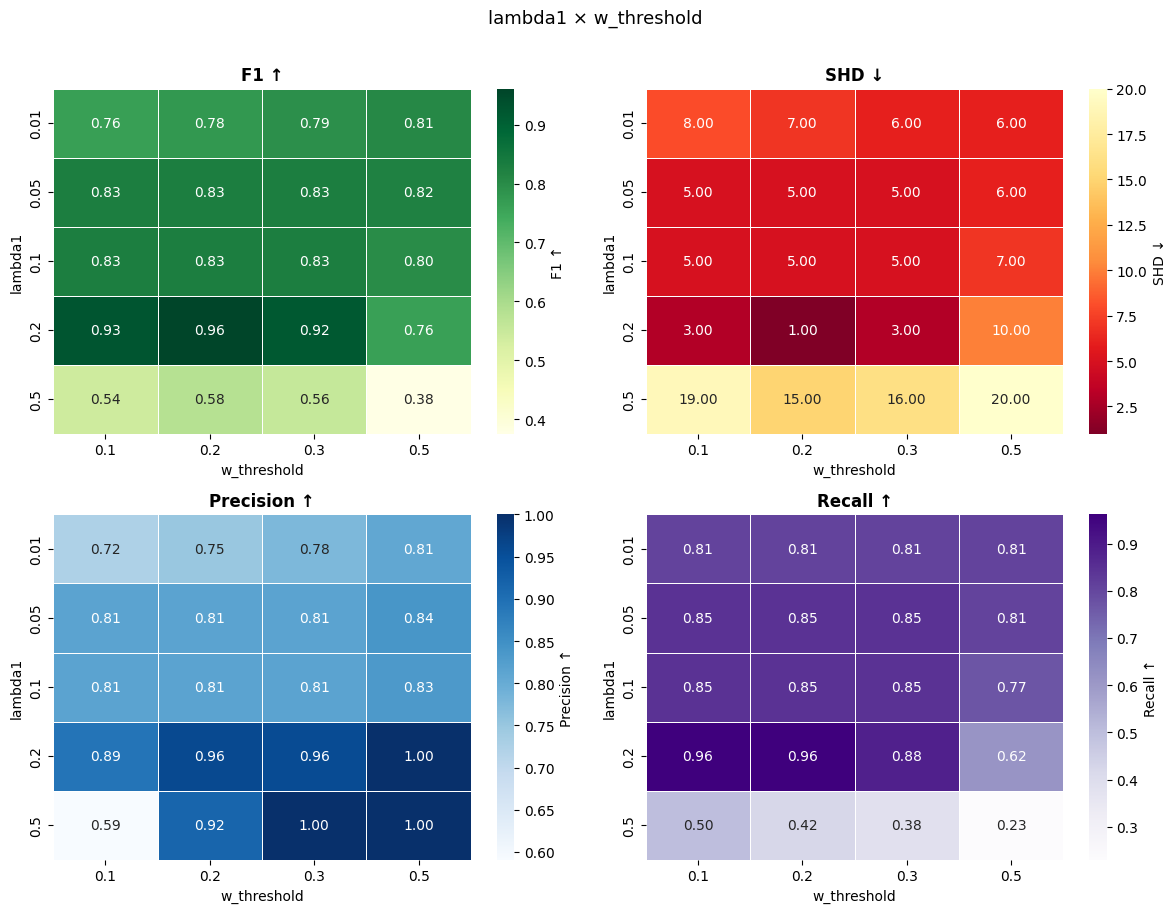

Saved → notears_gridsearch_heatmaps_lambda1_x_w_threshold.png


In [13]:
plot_heatmaps(results_df, PARAM_GRID)

2026-04-11 18:15:02,585 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,587 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,588 - c:\Users\danie\codice\uni\bayesianexp\.venv\Lib\site-packages\matplotlib\category.py[line:224] - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 18:15:02,590 - c:\Users\danie\co

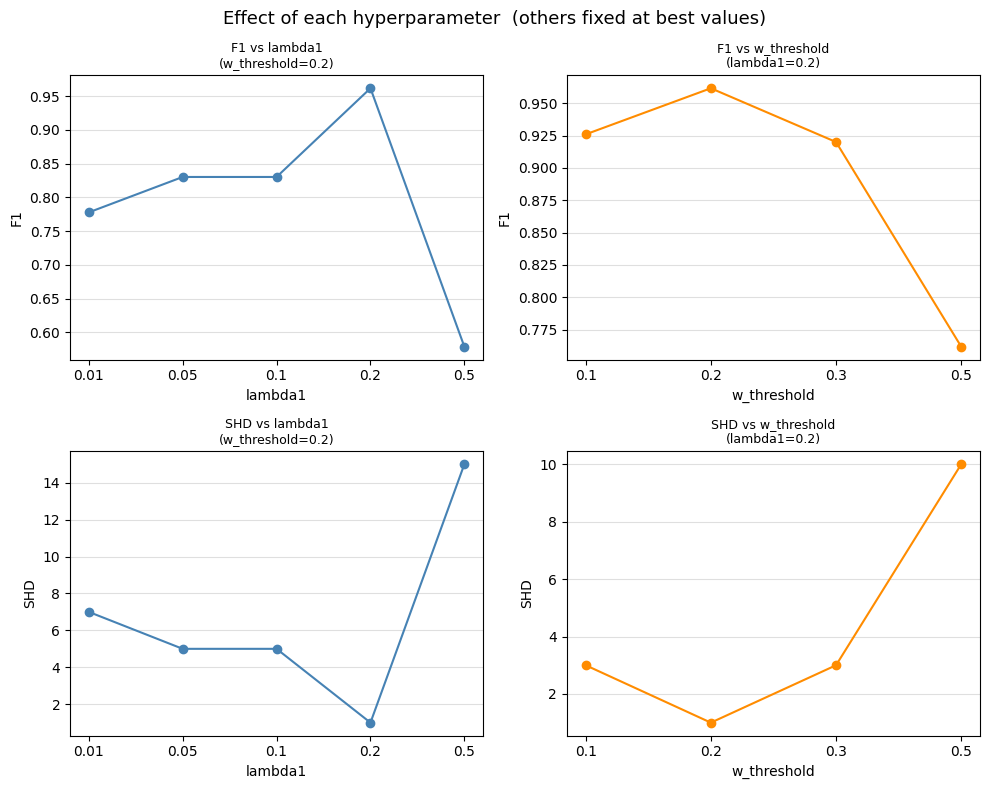

Saved → notears_gridsearch_profiles.png


In [14]:
plot_line_profiles(results_df, PARAM_GRID, best_params)

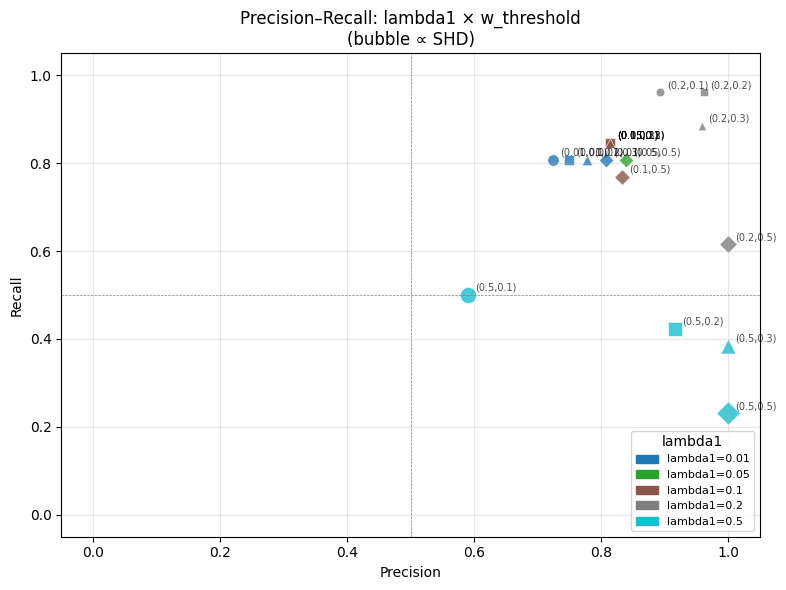

Saved → notears_gridsearch_scatter.png


In [15]:
plot_scatter(results_df, PARAM_GRID)

In [16]:
print_summary(results_df, PARAM_GRID)

Top 5 combinations by F1
 lambda1  w_threshold    f1  precision  recall  shd  n_learned
    0.20          0.2 0.962      0.962   0.962    1         26
    0.20          0.1 0.926      0.893   0.962    3         28
    0.20          0.3 0.920      0.958   0.885    3         24
    0.05          0.1 0.830      0.815   0.846    5         27
    0.10          0.2 0.830      0.815   0.846    5         27

Recommended: lambda1=0.2, w_threshold=0.2
  F1=0.962  Precision=0.962  Recall=0.962  SHD=1


## Something else optimization

### Results